In [10]:
#Uncomment the following line to install the datasets library if you haven't already
#%pip install datasets

# Sentiment Analysis on IMDb with PyTorch

This notebook covers a progression of models for binary text classification (positive / negative review) on the IMDb dataset.

| Stage | Representation | Model |
|---|---|---|
| 1 | One-hot bag-of-words | Logistic Regression |
| 2 | One-hot bag-of-words | Feed-Forward Neural Network |
| 3 | TF-IDF | Logistic Regression / FFNN |
| 4 | Learned embeddings | Embedding + mean pooling |
| 5 | Pretrained GloVe | Embedding + mean pooling |
| 6 | Sequences | RNN |
| 7 | Sequences | LSTM |
| 8 | Sequences | GRU |


In [11]:
import re
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 1. Data Loading

The IMDb dataset contains 25,000 training and 25,000 test movie reviews, each labeled positive (1) or negative (0).
We load it from the HuggingFace `datasets` library, then split the training set into train (80%) and validation (20%).


In [12]:
def load_splits():
    dataset = load_dataset("stanfordnlp/imdb")
    train_texts = dataset["train"]["text"]
    train_labels = np.array(dataset["train"]["label"], dtype=np.float32)
    test_texts = dataset["test"]["text"]
    test_labels = np.array(dataset["test"]["label"], dtype=np.float32)
    return train_texts, train_labels, test_texts, test_labels

train_texts, train_labels, test_texts, test_labels = load_splits()
print(f"Train: {len(train_texts)} | Test: {len(test_texts)}")
print(f"Example review: {train_texts[0][:200]}")
print(f"Label: {train_labels[0]}")


Train: 25000 | Test: 25000
Example review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
Label: 0.0


## 2. Text Processing

Before feeding text to a model, we need to convert it to numbers.

- **`clean_text`**: lowercase, remove HTML tags and non-alphabetic characters
- **`build_vocab`**: count word frequencies, keep the top `max_words`, assign integer indices
- **`vectorize_text`**: one-hot bag-of-words (1 if word present, 0 otherwise) — ignores word order and frequency
- **`encode`**: integer sequence encoding with padding/truncation — preserves word order, needed for RNNs


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)   # Remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text) # Remove punctuation and numbers
    return text

def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    most_common = counter.most_common(max_words - 2)
    word_index = {"<pad>": 0, "<unk>": 1}
    for i, (word, _) in enumerate(most_common, start=2): #start=2 to reserve 0 and 1 for <pad> and <unk>
        word_index[word] = i
    return word_index

def vectorize_text(text, word_index, max_words):
    """One-hot bag-of-words: 1 if word present, 0 otherwise."""
    vector = torch.zeros(max_words)
    for word in set(text.split()):
        if word in word_index:
            vector[word_index[word]] = 1
    return vector

def encode(text, word_index, max_len=200):
    """Integer sequence encoding with padding/truncation."""
    tokens = clean_text(text).split()
    sequence = [word_index.get(word, 1) for word in tokens]
    sequence = sequence[:max_len]
    if len(sequence) < max_len:
        sequence += [0] * (max_len - len(sequence))
    return torch.tensor(sequence, dtype=torch.long)


### Input representations — what does a review look like to each model?

Consider this toy review: **"great film bad acting"** with a vocabulary of 5 words:
`{<pad>:0, <unk>:1, great:2, film:3, bad:4, acting:5}`

---

#### Representation 1 — One-hot Bag-of-Words (→ Logistic Regression, FFNN)

Each review becomes a **single binary vector** of length `vocab_size`.
- 1 if the word appears in the review, 0 otherwise
- **No word order, no frequency** — just presence/absence

| index | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| token | `<pad>` | `<unk>` | `great` | `film` | `bad` | `acting` |
| value | 0 | 0 | **1** | **1** | **1** | **1** |

A batch of B reviews: shape **(B, vocab_size)** = **(256, 20 000)**

---

#### Representation 2 — TF-IDF (→ FFNN)

Same shape **(B, vocab_size)**, but values are **float weights** instead of 0/1.
- Common words (*"the"*, *"a"*) get low weight → near 0
- Rare but discriminative words (*"masterpiece"*) get high weight

| index | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| token | `<pad>` | `<unk>` | `great` | `film` | `bad` | `acting` |
| value | 0.0 | 0.0 | **0.81** | **0.32** | **0.71** | **0.65** |

---

#### Representation 3 — Integer Sequence (→ Embedding, RNN, LSTM, GRU)

Each review becomes a **sequence of integer word indices**, padded or truncated to `max_len`.
- Order is preserved (position matters)
- Padding tokens (0) fill short reviews to `max_len`

| position | 0 | 1 | 2 | 3 | 4 | 5 | … | 99 |
|---|---|---|---|---|---|---|---|---|
| token | `great` | `film` | `bad` | `acting` | `<pad>` | `<pad>` | … | `<pad>` |
| index | 2 | 3 | 4 | 5 | 0 | 0 | … | 0 |

A batch: shape **(B, max_len)** = **(512, 100)**

---

#### What the Embedding layer does (used by all sequence models)

`nn.Embedding` is a **lookup table**: each integer index is replaced by its dense vector of size `embed_dim`.

```
[2, 3, 4, 5, 0, ...]   →   [[0.3, -0.1, ...],    # vector for "great"  (E values)
                             [0.1,  0.9, ...],    # vector for "film"
                             [-0.5, 0.2, ...],    # vector for "bad"
                             [0.7,  0.4, ...],    # vector for "acting"
                             [0.0,  0.0, ...],    # <pad> → always zero
                             ...]
```

Shape after embedding: **(B, max_len, embed_dim)** = **(512, 100, 200)**

---

#### What each model does with the embedded matrix (B, L, E)

| Model | Operation | Output shape fed to classifier |
|---|---|---|
| EmbeddingClassifier | `.mean(dim=1)` — average all L vectors | **(B, E)** = (512, 200) |
| RNN | last hidden state `hidden[-1]` | **(B, H)** = (512, 128) |
| LSTM (bidir) | concat forward + backward last hidden | **(B, 2H)** = (512, 256) |
| GRU (bidir) | concat forward + backward last hidden | **(B, 2H)** = (512, 256) |

In all cases the classifier `nn.Linear(*, 1)` produces **(B, 1)**, squeezed to **(B,)** — one logit per review.


## 3. Dataset Classes & Loaders

Three dataset variants, each using a different text representation:

- **`IMDBDataset`** — one-hot bag-of-words (for logistic regression and FFNN)
- **`TfidfDataset`** — TF-IDF features (weights words by importance across documents)
- **`IMDBDatasetEmbed`** — integer sequences (for embedding layers, RNNs, LSTMs, GRUs)


In [14]:
class IMDBDataset(Dataset):
    """One-hot bag-of-words representation."""
    def __init__(self, texts, labels, word_index, max_words):
        self.texts = texts
        self.labels = labels
        self.word_index = word_index
        self.max_words = max_words

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = vectorize_text(self.texts[idx], self.word_index, self.max_words)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


class TfidfDataset(Dataset):
    """TF-IDF features (bigrams, stopword removal)."""
    def __init__(self, texts, labels, max_words=20000, train=True, tr_texts=None):
        self.labels = labels
        self.vectorizer = TfidfVectorizer(
            max_features=max_words, ngram_range=(1, 2),
            stop_words="english", min_df=5  #min document frequency to filter out rare words
        )
        if train:
            self.X = torch.tensor(self.vectorizer.fit_transform(texts).toarray(), dtype=torch.float32)
        else:
            self.vectorizer.fit(tr_texts)
            self.X = torch.tensor(self.vectorizer.transform(texts).toarray(), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.X[idx], torch.tensor(self.labels[idx], dtype=torch.float32)


class IMDBDatasetEmbed(Dataset):
    """Integer sequence encoding (for embedding layers and sequential models)."""
    def __init__(self, texts, labels, word_index, max_words, max_len=200):
        self.texts = texts
        self.labels = labels
        self.word_index = word_index
        self.max_words = max_words
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode(self.texts[idx], self.word_index, self.max_len)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


In [15]:
def _make_loaders(full_train, test_dataset, batch_size, val_perc=0.8):
    train_size = int(val_perc * len(full_train))
    val_size = len(full_train) - train_size
    train_dataset, val_dataset = random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size),
        DataLoader(test_dataset, batch_size=batch_size),
    )

def load_imdb_dataset(max_words=10000, batch_size=256, val_perc=0.8):
    """One-hot bag-of-words loaders."""
    word_index = build_vocab(train_texts, max_words)
    full_train = IMDBDataset(train_texts, train_labels, word_index, max_words)
    test_ds = IMDBDataset(test_texts, test_labels, word_index, max_words)
    return _make_loaders(full_train, test_ds, batch_size, val_perc)

def load_dataset_tfidf(max_words=10000, batch_size=256, val_perc=0.8):
    """TF-IDF loaders."""
    full_train = TfidfDataset(train_texts, train_labels, max_words, train=True)
    test_ds = TfidfDataset(test_texts, test_labels, max_words, train=False, tr_texts=train_texts)
    return _make_loaders(full_train, test_ds, batch_size, val_perc)

def load_dataset_embed(max_words=10000, max_len=200, batch_size=512, val_perc=0.8):
    """Integer sequence loaders (for embedding / RNN models)."""
    word_index = build_vocab(train_texts, max_words)
    full_train = IMDBDatasetEmbed(train_texts, train_labels, word_index, max_words, max_len)
    test_ds = IMDBDatasetEmbed(test_texts, test_labels, word_index, max_words, max_len)
    return _make_loaders(full_train, test_ds, batch_size, val_perc)


## 4. Pretrained GloVe Embeddings

GloVe (Global Vectors for Word Representation) provides pretrained word vectors trained on large corpora.
Instead of learning embeddings from scratch, we initialise `nn.Embedding` with these vectors.

The cell below will automatically download `glove.6B.zip` (~822 MB) from Stanford if the file is not found locally.


In [16]:
import urllib.request
import zipfile
from pathlib import Path


def download_glove(glove_path="glove.6B.100d.txt"):
    glove_path = Path(glove_path)
    if glove_path.exists():
        print(f"GloVe file found: {glove_path}")
        return str(glove_path)

    zip_path = glove_path.parent / "glove.6B.zip"
    url = "https://nlp.stanford.edu/data/glove.6B.zip"

    if not zip_path.exists():
        print(f"Downloading GloVe from {url} ...")
        urllib.request.urlretrieve(url, zip_path)
        print("Download complete.")

    print(f"Extracting {glove_path.name} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extract(glove_path.name, glove_path.parent)
    print(f"Extracted to {glove_path}")
    return str(glove_path)


def load_glove_embeddings(glove_path, word_index, embed_dim):
    embeddings_index = {}
    with open(glove_path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = vector

    vocab_size = len(word_index)
    embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, embed_dim))
    embedding_matrix[0] = np.zeros(embed_dim)  # PAD token = zeros

    found = 0
    for word, i in word_index.items():
        if word in embeddings_index:
            embedding_matrix[i] = embeddings_index[word]
            found += 1

    print(f"Found {found}/{vocab_size} pretrained vectors")
    return torch.tensor(embedding_matrix, dtype=torch.float32)


## 5. Training & Evaluation Utilities


In [17]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            total_loss += criterion(outputs, y).item()
            preds = (outputs > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), correct / total


def train(model, train_loader, val_loader, criterion, epochs=5, lr=0.001):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
              f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}")

    return history


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend()

    plt.tight_layout()
    plt.show()


## 6. Models

### 6.1 Logistic Regression

A single linear layer followed by sigmoid. Equivalent to logistic regression.
Baseline: no hidden layers, no feature interactions.


In [18]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x)).squeeze()  #squeeze to remove extra dimensions for binary classification


### 6.2 Feed-Forward Neural Network

Configurable hidden layers via `topology` list. Learns non-linear feature combinations.
Still operates on bag-of-words or TF-IDF — no word order information.


In [19]:
class FFNN(nn.Module):
    def __init__(self, input_dim, topology=[50], dropout=0.0):
        super().__init__()
        layers = []
        if not topology:
            layers.append(nn.Linear(input_dim, 1))
        else:
            layers += [nn.Linear(input_dim, topology[0]), nn.ReLU()]
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            for i in range(1, len(topology)):
                layers += [nn.Linear(topology[i-1], topology[i]), nn.ReLU()]
                if dropout > 0.0:
                    layers.append(nn.Dropout(dropout))
            layers += [nn.Linear(topology[-1], 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze()


### 6.3 Embedding Classifier

Learns a dense vector (embedding) for each word. Averages all word vectors in the sequence, then classifies.
Better than one-hot: similar words get similar vectors. Still loses word order (mean pooling).

`EmbeddingPretrained` initialises from GloVe vectors instead of random.


In [20]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):  # x: (B, L)
        pooled = self.embedding(x).mean(dim=1)  # (B, E)   #average pooling to get a fixed-size representation of the sequence
        return self.fc(pooled).squeeze(1)


class EmbeddingPretrained(nn.Module):
    def __init__(self, glove_path, word_index, embed_dim, freeze=False):
        super().__init__()
        embedding_matrix = load_glove_embeddings(glove_path, word_index, embed_dim)
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze, padding_idx=0)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):  # x: (B, L)
        pooled = self.embedding(x).mean(dim=1)  # (B, E)
        return self.fc(pooled).squeeze(1) 


### 6.4 RNN

Processes the sequence token by token, passing a hidden state forward.
The final hidden state summarises the entire review.
Suffers from vanishing gradients on long sequences — LSTM/GRU solve this.


In [21]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):  # x: (B, L)
        embedded = self.embedding(x)             # (B, L, E)
        _, hidden = self.rnn(embedded)           # hidden: (num_layers, B, H)
        return self.fc(hidden[-1]).squeeze(1)    # last layer hidden state


### 6.5 LSTM

Adds input, forget, and output gates to control what information to keep or discard.
Supports multiple layers, dropout between layers, and bidirectional processing.
Bidirectional: runs the sequence forward and backward, doubles the effective hidden size.


In [22]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, 1)

    def forward(self, x):  # x: (B, L)
        embedded = self.embedding(x)                     # (B, L, E)
        # LSTM returns (output, (h_n, c_n)):
        #   output: hidden state at every time step — not needed, we only want the final summary
        #   h_n (hidden): final hidden state — what the network "remembers", used for classification
        #   c_n (cell): internal long-term memory gate state — not directly interpretable, discarded
        _, (hidden, _) = self.lstm(embedded)             # hidden: (num_layers*dirs, B, H)
        if self.lstm.bidirectional:
            # hidden[-2]: last layer forward direction; hidden[-1]: last layer backward direction
            # concatenate both to get the full bidirectional representation → (B, 2*H)
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)    #dim1 is the feature dimension
        else:
            last_hidden = hidden[-1]
        return self.fc(self.dropout(last_hidden)).squeeze(1)


### 6.6 GRU

Simpler than LSTM: two gates (reset, update) instead of three. Fewer parameters, similar performance.
Often preferred when training speed matters or datasets are smaller.


In [23]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, 1)

    def forward(self, x):  # x: (B, L)
        embedded = self.embedding(x)           # (B, L, E)
        _, hidden = self.gru(embedded)         # hidden: (num_layers*dirs, B, H)
        if self.gru.bidirectional:
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]
        return self.fc(self.dropout(last_hidden)).squeeze(1)


## 7. Experiments

Run each cell independently to train and evaluate a model. Results are printed per epoch and plotted at the end.


Epoch 01/20 | train loss: 0.4935 | train acc: 0.8640 | val loss: 0.5098 | val acc: 0.8394
Epoch 02/20 | train loss: 0.4056 | train acc: 0.8911 | val loss: 0.4339 | val acc: 0.8616
Epoch 03/20 | train loss: 0.3524 | train acc: 0.9073 | val loss: 0.3911 | val acc: 0.8694
Epoch 04/20 | train loss: 0.3162 | train acc: 0.9174 | val loss: 0.3632 | val acc: 0.8746
Epoch 05/20 | train loss: 0.2891 | train acc: 0.9257 | val loss: 0.3442 | val acc: 0.8772
Epoch 06/20 | train loss: 0.2655 | train acc: 0.9327 | val loss: 0.3299 | val acc: 0.8790
Epoch 07/20 | train loss: 0.2483 | train acc: 0.9386 | val loss: 0.3198 | val acc: 0.8800
Epoch 08/20 | train loss: 0.2331 | train acc: 0.9432 | val loss: 0.3109 | val acc: 0.8820
Epoch 09/20 | train loss: 0.2197 | train acc: 0.9476 | val loss: 0.3044 | val acc: 0.8816
Epoch 10/20 | train loss: 0.2083 | train acc: 0.9515 | val loss: 0.2994 | val acc: 0.8822
Epoch 11/20 | train loss: 0.1977 | train acc: 0.9554 | val loss: 0.2946 | val acc: 0.8828
Epoch 12/2

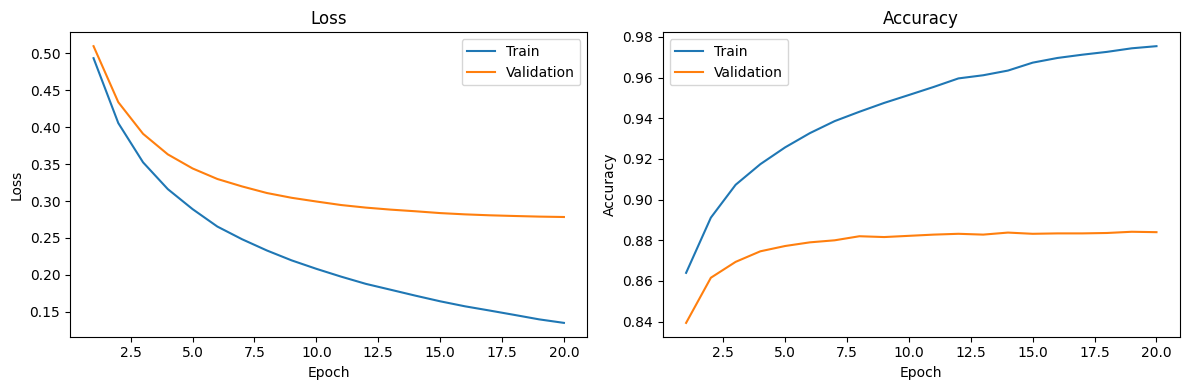

In [24]:
# --- Logistic Regression (one-hot) ---
max_words = 20000
train_loader, val_loader, test_loader = load_imdb_dataset(max_words=max_words)
model = SimpleClassifier(max_words)
criterion = nn.BCELoss()
history = train(model, train_loader, val_loader, criterion, epochs=20)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


Epoch 01/10 | train loss: 0.2364 | train acc: 0.9256 | val loss: 0.3044 | val acc: 0.8790
Epoch 02/10 | train loss: 0.1357 | train acc: 0.9639 | val loss: 0.2784 | val acc: 0.8840
Epoch 03/10 | train loss: 0.0829 | train acc: 0.9818 | val loss: 0.2879 | val acc: 0.8854
Epoch 04/10 | train loss: 0.0521 | train acc: 0.9910 | val loss: 0.3099 | val acc: 0.8818
Epoch 05/10 | train loss: 0.0343 | train acc: 0.9958 | val loss: 0.3337 | val acc: 0.8796
Epoch 06/10 | train loss: 0.0232 | train acc: 0.9973 | val loss: 0.3659 | val acc: 0.8768
Epoch 07/10 | train loss: 0.0153 | train acc: 0.9987 | val loss: 0.3937 | val acc: 0.8796
Epoch 08/10 | train loss: 0.0109 | train acc: 0.9994 | val loss: 0.4267 | val acc: 0.8770
Epoch 09/10 | train loss: 0.0077 | train acc: 0.9996 | val loss: 0.4380 | val acc: 0.8736
Epoch 10/10 | train loss: 0.0056 | train acc: 0.9997 | val loss: 0.4821 | val acc: 0.8736

Test Accuracy: 0.8657


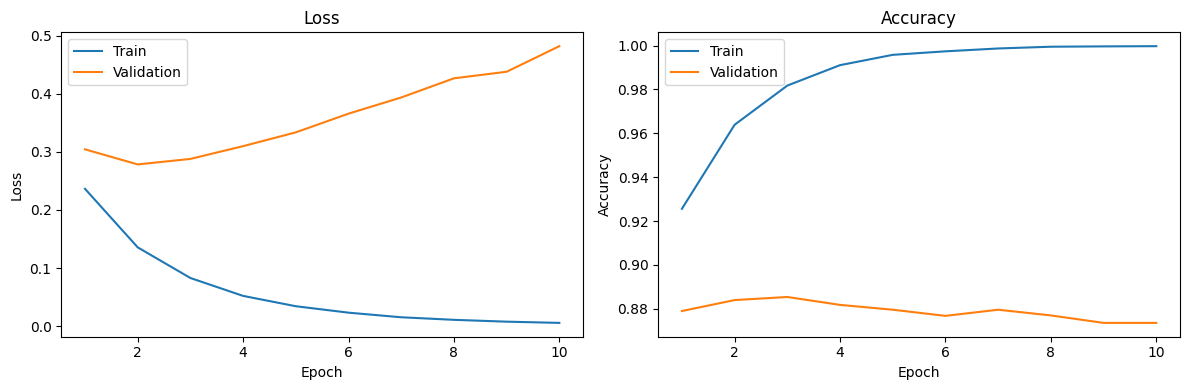

In [25]:
# --- FFNN (one-hot) ---
max_words = 20000
train_loader, val_loader, test_loader = load_imdb_dataset(max_words=max_words)
model = FFNN(max_words, topology=[100], dropout=0.5)
criterion = nn.BCELoss()
history = train(model, train_loader, val_loader, criterion, epochs=10)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


Epoch 01/20 | train loss: 0.4169 | train acc: 0.9014 | val loss: 0.4431 | val acc: 0.8722
Epoch 02/20 | train loss: 0.2273 | train acc: 0.9373 | val loss: 0.2908 | val acc: 0.8948
Epoch 03/20 | train loss: 0.1547 | train acc: 0.9617 | val loss: 0.2543 | val acc: 0.8978
Epoch 04/20 | train loss: 0.1132 | train acc: 0.9752 | val loss: 0.2469 | val acc: 0.8974
Epoch 05/20 | train loss: 0.0833 | train acc: 0.9856 | val loss: 0.2499 | val acc: 0.8972
Epoch 06/20 | train loss: 0.0625 | train acc: 0.9923 | val loss: 0.2572 | val acc: 0.8952
Epoch 07/20 | train loss: 0.0469 | train acc: 0.9963 | val loss: 0.2676 | val acc: 0.8916
Epoch 08/20 | train loss: 0.0358 | train acc: 0.9980 | val loss: 0.2801 | val acc: 0.8908
Epoch 09/20 | train loss: 0.0274 | train acc: 0.9990 | val loss: 0.2926 | val acc: 0.8878
Epoch 10/20 | train loss: 0.0217 | train acc: 0.9995 | val loss: 0.3051 | val acc: 0.8868
Epoch 11/20 | train loss: 0.0170 | train acc: 0.9996 | val loss: 0.3176 | val acc: 0.8870
Epoch 12/2

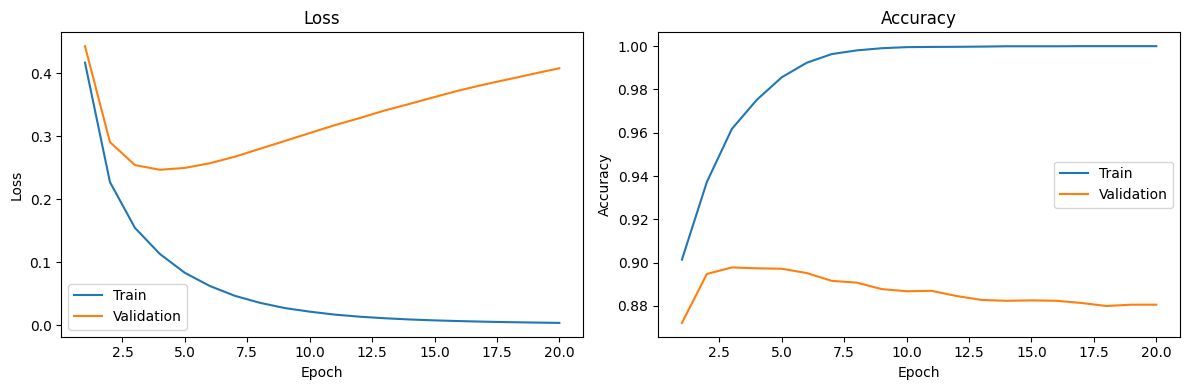

In [26]:
# --- FFNN (TF-IDF) ---
max_words = 20000
train_loader, val_loader, test_loader = load_dataset_tfidf(max_words=max_words)
model = FFNN(max_words, topology=[100], dropout=0.2)
criterion = nn.BCELoss()
history = train(model, train_loader, val_loader, criterion, epochs=20)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


Epoch 01/20 | train loss: 0.6774 | train acc: 0.4998 | val loss: 0.6776 | val acc: 0.5034
Epoch 02/20 | train loss: 0.6588 | train acc: 0.5117 | val loss: 0.6590 | val acc: 0.5154
Epoch 03/20 | train loss: 0.6336 | train acc: 0.5491 | val loss: 0.6362 | val acc: 0.5486
Epoch 04/20 | train loss: 0.6028 | train acc: 0.5911 | val loss: 0.6069 | val acc: 0.5848
Epoch 05/20 | train loss: 0.5640 | train acc: 0.6529 | val loss: 0.5722 | val acc: 0.6374
Epoch 06/20 | train loss: 0.5259 | train acc: 0.7077 | val loss: 0.5366 | val acc: 0.6866
Epoch 07/20 | train loss: 0.4892 | train acc: 0.7432 | val loss: 0.5026 | val acc: 0.7234
Epoch 08/20 | train loss: 0.4525 | train acc: 0.7689 | val loss: 0.4727 | val acc: 0.7512
Epoch 09/20 | train loss: 0.4229 | train acc: 0.8013 | val loss: 0.4478 | val acc: 0.7770
Epoch 10/20 | train loss: 0.3985 | train acc: 0.8214 | val loss: 0.4275 | val acc: 0.7974
Epoch 11/20 | train loss: 0.3800 | train acc: 0.8363 | val loss: 0.4110 | val acc: 0.8112
Epoch 12/2

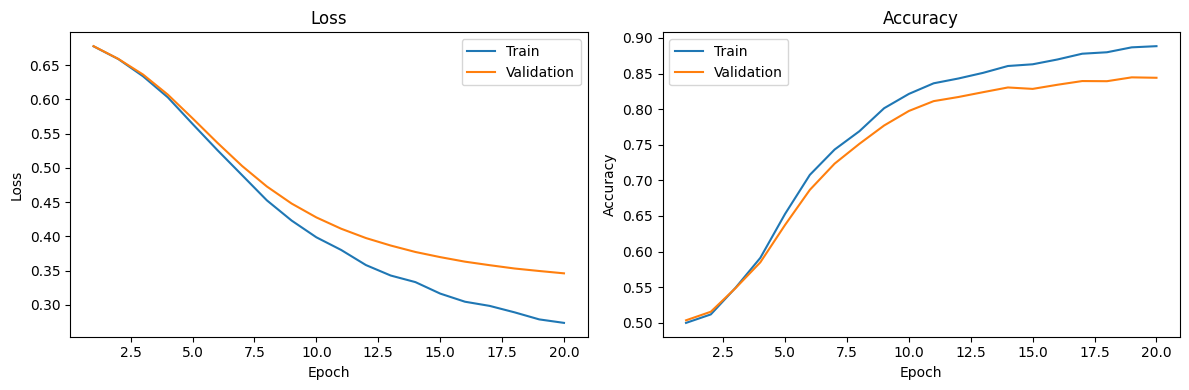

In [27]:
# --- Embedding Classifier (learned embeddings) ---
max_words = 20000
embed_dim = 200
train_loader, val_loader, test_loader = load_dataset_embed(max_words=max_words)
model = EmbeddingClassifier(max_words, embed_dim)
criterion = nn.BCEWithLogitsLoss()
history = train(model, train_loader, val_loader, criterion, epochs=20)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


GloVe file found: glove.6B.100d.txt
Found 10006/20000 pretrained vectors
Epoch 01/30 | train loss: 0.6821 | train acc: 0.4994 | val loss: 0.6824 | val acc: 0.5026
Epoch 02/30 | train loss: 0.6699 | train acc: 0.4995 | val loss: 0.6696 | val acc: 0.5028
Epoch 03/30 | train loss: 0.6524 | train acc: 0.5093 | val loss: 0.6538 | val acc: 0.5114
Epoch 04/30 | train loss: 0.6303 | train acc: 0.5526 | val loss: 0.6338 | val acc: 0.5538
Epoch 05/30 | train loss: 0.6068 | train acc: 0.5864 | val loss: 0.6105 | val acc: 0.5820
Epoch 06/30 | train loss: 0.5801 | train acc: 0.6328 | val loss: 0.5851 | val acc: 0.6218
Epoch 07/30 | train loss: 0.5504 | train acc: 0.6774 | val loss: 0.5586 | val acc: 0.6672
Epoch 08/30 | train loss: 0.5218 | train acc: 0.7110 | val loss: 0.5321 | val acc: 0.6974
Epoch 09/30 | train loss: 0.4937 | train acc: 0.7418 | val loss: 0.5068 | val acc: 0.7262
Epoch 10/30 | train loss: 0.4662 | train acc: 0.7626 | val loss: 0.4835 | val acc: 0.7424
Epoch 11/30 | train loss: 0

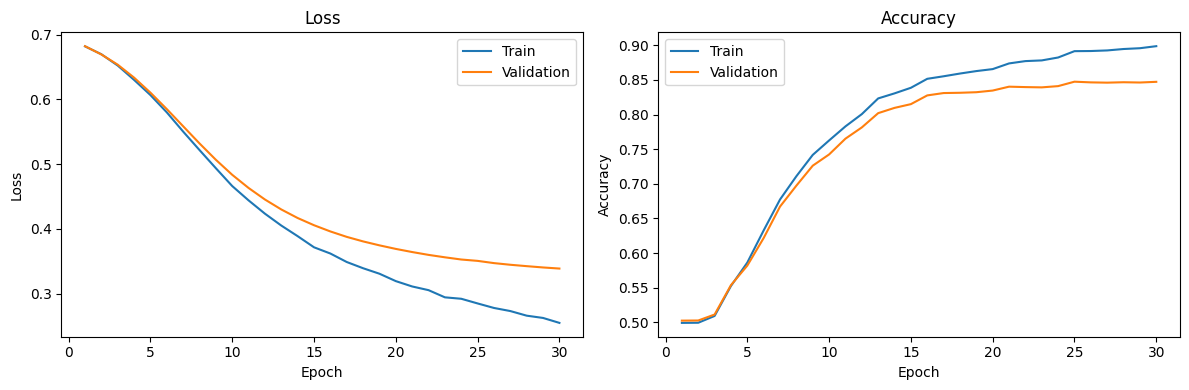

In [28]:
# --- Embedding Classifier (pretrained GloVe) ---
max_words = 20000
embed_dim = 100  # must match the GloVe file (100d)
glove_path = download_glove("glove.6B.100d.txt")
word_index = build_vocab(train_texts, max_words)
train_loader, val_loader, test_loader = load_dataset_embed(max_words=max_words, max_len=200)
model = EmbeddingPretrained(glove_path, word_index, embed_dim)
criterion = nn.BCEWithLogitsLoss()
history = train(model, train_loader, val_loader, criterion, epochs=30)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


Epoch 01/20 | train loss: 0.6804 | train acc: 0.5072 | val loss: 0.6909 | val acc: 0.5038
Epoch 02/20 | train loss: 0.6615 | train acc: 0.5488 | val loss: 0.6826 | val acc: 0.5422
Epoch 03/20 | train loss: 0.6676 | train acc: 0.5275 | val loss: 0.6913 | val acc: 0.5130
Epoch 04/20 | train loss: 0.6464 | train acc: 0.5527 | val loss: 0.6822 | val acc: 0.5272
Epoch 05/20 | train loss: 0.6344 | train acc: 0.5771 | val loss: 0.6878 | val acc: 0.5434
Epoch 06/20 | train loss: 0.6009 | train acc: 0.6649 | val loss: 0.6776 | val acc: 0.5898
Epoch 07/20 | train loss: 0.5641 | train acc: 0.6801 | val loss: 0.6695 | val acc: 0.6004
Epoch 08/20 | train loss: 0.6194 | train acc: 0.6204 | val loss: 0.7217 | val acc: 0.5650
Epoch 09/20 | train loss: 0.5561 | train acc: 0.7392 | val loss: 0.6763 | val acc: 0.6348
Epoch 10/20 | train loss: 0.5722 | train acc: 0.6849 | val loss: 0.7257 | val acc: 0.5556
Epoch 11/20 | train loss: 0.4953 | train acc: 0.7524 | val loss: 0.6789 | val acc: 0.6466
Epoch 12/2

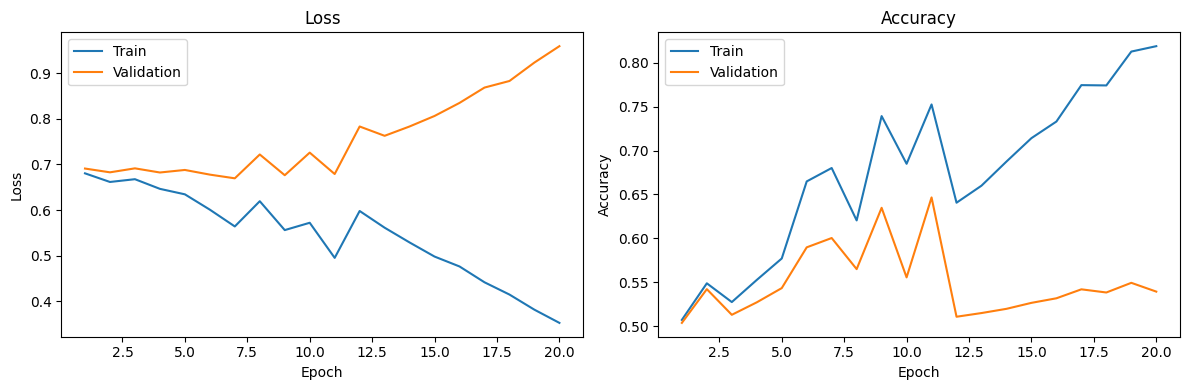

In [29]:
# --- RNN ---
max_words = 20000
embed_dim = 200
train_loader, val_loader, test_loader = load_dataset_embed(max_words=max_words, max_len=100)
model = RNNClassifier(max_words, embed_dim, hidden_dim=128, num_layers=1)
criterion = nn.BCEWithLogitsLoss()
history = train(model, train_loader, val_loader, criterion, epochs=20)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


Epoch 01/20 | train loss: 0.6181 | train acc: 0.6230 | val loss: 0.6323 | val acc: 0.6076
Epoch 02/20 | train loss: 0.5040 | train acc: 0.7299 | val loss: 0.5410 | val acc: 0.7024
Epoch 03/20 | train loss: 0.4735 | train acc: 0.7389 | val loss: 0.5333 | val acc: 0.7154
Epoch 04/20 | train loss: 0.3494 | train acc: 0.8540 | val loss: 0.4669 | val acc: 0.7822
Epoch 05/20 | train loss: 0.4200 | train acc: 0.7782 | val loss: 0.5926 | val acc: 0.7328
Epoch 06/20 | train loss: 0.2959 | train acc: 0.8927 | val loss: 0.4679 | val acc: 0.8024
Epoch 07/20 | train loss: 0.2405 | train acc: 0.9107 | val loss: 0.5079 | val acc: 0.8094
Epoch 08/20 | train loss: 0.1884 | train acc: 0.9354 | val loss: 0.5197 | val acc: 0.8092
Epoch 09/20 | train loss: 0.1422 | train acc: 0.9374 | val loss: 0.6015 | val acc: 0.7934
Epoch 10/20 | train loss: 0.1588 | train acc: 0.9254 | val loss: 0.7733 | val acc: 0.7750
Epoch 11/20 | train loss: 0.0793 | train acc: 0.9769 | val loss: 0.6346 | val acc: 0.8060
Epoch 12/2

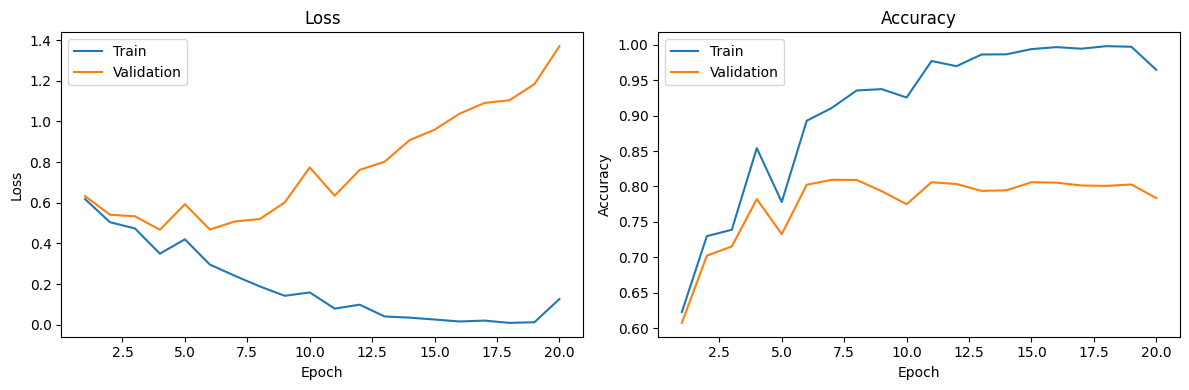

In [30]:
# --- LSTM (bidirectional, 2 layers) ---
max_words = 20000
embed_dim = 200
train_loader, val_loader, test_loader = load_dataset_embed(max_words=max_words, max_len=100)
model = LSTMClassifier(max_words, embed_dim, hidden_dim=128, num_layers=2, bidirectional=True, dropout=0.5)
criterion = nn.BCEWithLogitsLoss()
history = train(model, train_loader, val_loader, criterion, epochs=20)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


Epoch 01/20 | train loss: 0.6299 | train acc: 0.5989 | val loss: 0.6531 | val acc: 0.5786
Epoch 02/20 | train loss: 0.4990 | train acc: 0.7651 | val loss: 0.5498 | val acc: 0.7136
Epoch 03/20 | train loss: 0.4054 | train acc: 0.8201 | val loss: 0.4970 | val acc: 0.7590
Epoch 04/20 | train loss: 0.3567 | train acc: 0.8222 | val loss: 0.4842 | val acc: 0.7522
Epoch 05/20 | train loss: 0.2914 | train acc: 0.8776 | val loss: 0.4658 | val acc: 0.7870
Epoch 06/20 | train loss: 0.2747 | train acc: 0.8752 | val loss: 0.4646 | val acc: 0.7678
Epoch 07/20 | train loss: 0.2574 | train acc: 0.9062 | val loss: 0.5386 | val acc: 0.7910
Epoch 08/20 | train loss: 0.1791 | train acc: 0.9363 | val loss: 0.5364 | val acc: 0.7990
Epoch 09/20 | train loss: 0.1289 | train acc: 0.9592 | val loss: 0.5252 | val acc: 0.7968
Epoch 10/20 | train loss: 0.1315 | train acc: 0.9623 | val loss: 0.6212 | val acc: 0.7970
Epoch 11/20 | train loss: 0.0830 | train acc: 0.9605 | val loss: 0.7235 | val acc: 0.7866
Epoch 12/2

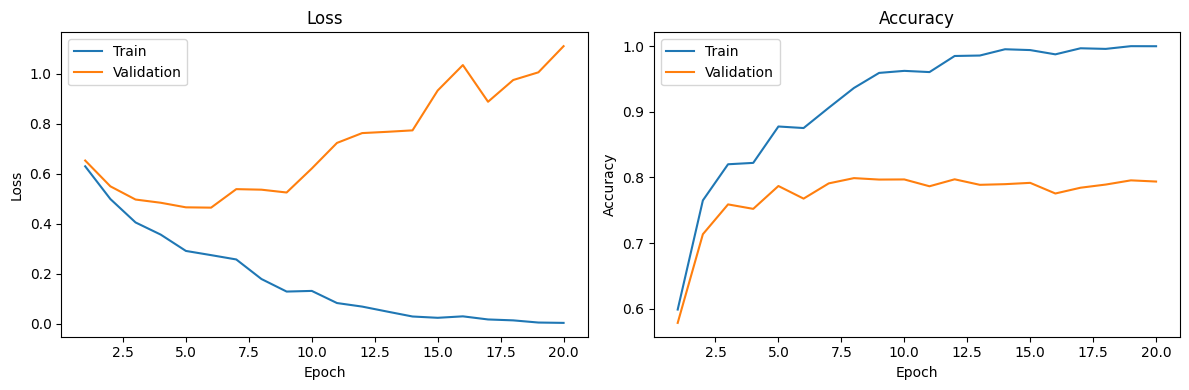

In [31]:
# --- GRU (bidirectional) ---
max_words = 20000
embed_dim = 200
train_loader, val_loader, test_loader = load_dataset_embed(max_words=max_words, max_len=100)
model = GRUClassifier(max_words, embed_dim, hidden_dim=128, num_layers=1, bidirectional=True, dropout=0.3)
criterion = nn.BCEWithLogitsLoss()
history = train(model, train_loader, val_loader, criterion, epochs=20)
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")
plot_history(history)


## 8. Results & Analysis

### Actual test accuracies

| Model | Representation | Test Accuracy |
|---|---|---|
| Logistic Regression | One-hot BoW | **88.13 %** |
| FFNN (one-hot) | One-hot BoW | 86.57 % |
| FFNN (TF-IDF) | TF-IDF bigrams | 85.79 % |
| Embedding Classifier | Learned embeddings | 83.89 % |
| Embedding + GloVe | Pretrained GloVe | 84.66 % |
| RNN | Sequences | 53.40 % |
| LSTM (bidir, 2L) | Sequences | 77.87 % |
| GRU (bidir) | Sequences | 78.88 % |

---

### Are these results expected?

**Yes — and they reveal an important lesson.**

**Bag-of-words wins** (LR at 88 %) because IMDb sentiment is largely keyword-driven: words like *great* or *terrible* are highly informative, and their order matters little. Logistic regression on BoW is a well-known strong baseline for this dataset.

**RNN at 53 %** is essentially random (50 % baseline for binary classification). With `max_len=100`, gradients must propagate back through 100 time steps, vanishing before they reach the early tokens. The model never really learns.

**LSTM/GRU at ~78 %** recover partially thanks to their gating mechanisms, but still fall below the simple models. The likely causes are: `max_len=100` truncates many reviews mid-sentence; 20 epochs may not be enough without a scheduler; and sequence models in general need more careful tuning to beat strong BoW baselines on IMDb.

**Key takeaway**: more complex ≠ better. Sequence models shine when word order is structurally important (e.g. negation: *"not bad"*) or sequences are long and hierarchical. For bag-of-sentiment tasks like IMDb, a well-tuned logistic regression is hard to beat.
